# Хакатон ChemAI: Predict the Cure

**НИЯУ МИФИ, группа М25-555**

**Состав команды:**

| Участник | Роль в проекте |
|----------|----------------|
| Анастасия Волконская | тимлид, интегратор ноутбука |
| Мария Макарова | EDA и данные (§2–§3) |
| Артур Сидоров | матчасть PCA/ICA (§5–§6) |
| Максим Власюк | модели и CV, stacking (§7–§8) |
| Алина Давыденко | тексты выводов, вычитка |

**Kaggle:** Задача хакатона. ChemAI: Predict the Cure, команда 39

https://www.kaggle.com/competitions/chem-ai-predict-the-cure/overview

Единый самодостаточный ноутбук → submission **349.31** (OOF stacking, ClusterKFold).


In [1]:
# @title Установка зависимостей
"""
Проверка и установка pip-пакетов.
Репозиторий Git не нужен — ноутбук полностью автономный.
"""
import importlib
import subprocess
import sys

# --- список зависимостей для EDA, ML и stacking ---
REQUIRED = (
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "lightgbm", "xgboost",
)
for pkg in REQUIRED:
    mod = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        # Colab / чистое окружение: тихая установка недостающего пакета
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Зависимости OK")


Зависимости OK


In [2]:
# @title §1. Импорты и константы
"""
Общие библиотеки, seed и настройки графиков для всего ноутбука.
"""
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import FastICA, PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# --- воспроизводимость экспериментов ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- таргеты соревнования (метрика = mean RMSE по ним) ---
TARGETS = ("IC50", "CC50", "SI")

# --- единый стиль графиков EDA ---
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 10})
sns.set_theme(style="whitegrid")
print("RANDOM_STATE =", RANDOM_STATE)


RANDOM_STATE = 42


⚠️ **Данные:** нужны `train.csv` и `test.csv` с Kaggle.

- Положите файлы рядом с ноутбуком, в папку `data/` или загрузите через Colab (ячейка §2).
- Репозиторий Git **не требуется**.

In [3]:
# @title §2. Загрузка данных
"""
Ищем train.csv / test.csv по нескольким путям.
В Google Colab — fallback через files.upload().
"""
TRAIN_NAME, TEST_NAME = "train.csv", "test.csv"


def find_data_file(name: str) -> Path | None:
    """Ищет CSV в cwd, data/, /content/ — типичные пути Colab и локального запуска."""
    for p in (
        Path(name),
        Path("data") / name,
        Path("/content") / name,
        Path("/content/data") / name,
    ):
        if p.is_file():
            return p.resolve()
    return None


# --- поиск файлов на диске ---
train_path = find_data_file(TRAIN_NAME)
test_path = find_data_file(TEST_NAME)

# --- fallback: ручная загрузка в Google Colab ---
if train_path is None or test_path is None:
    try:
        from google.colab import files  # type: ignore
        print("Загрузите train.csv и test.csv с Kaggle:")
        uploaded = files.upload()
        for fname, data in uploaded.items():
            Path(fname).write_bytes(data)
        train_path = find_data_file(TRAIN_NAME)
        test_path = find_data_file(TEST_NAME)
    except ImportError:
        pass

if train_path is None or test_path is None:
    raise FileNotFoundError("Не найдены train.csv / test.csv — скачайте с Kaggle.")

# --- чтение таблиц ---
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# --- список признаков (всё кроме index и таргетов) ---
feature_cols = [c for c in train_df.columns if c not in ("index", *TARGETS)]
print("train:", train_df.shape, "| test:", test_df.shape)
print("числовых признаков:", len(feature_cols))
train_df.head(3)


Загрузите train.csv и test.csv с Kaggle:


Saving test.csv to test.csv
Saving train.csv to train.csv
train: (751, 214) | test: (250, 211)
числовых признаков: 210


,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0


## 📊 Выводы: загрузка данных (§2)

| Набор | Строк | Колонок |
|-------|-------|---------|
| train | 751 | 214 |
| test | 250 | 211 |

**Интерпретация:**

- В train есть три таргета (`IC50`, `CC50`, `SI`) и 210 числовых дескрипторов молекул.
- Имена признаков в train и test совпадают — можно обучать и предсказывать без переименования.
- Пропусков в таргетах нет; часть дескрипторов имеет NA (см. EDA).

**Вывод:** данные готовы к feature engineering и CV.

**✅ Следующий шаг:** EDA таргетов и проверка связи SI ≈ CC50/IC50.


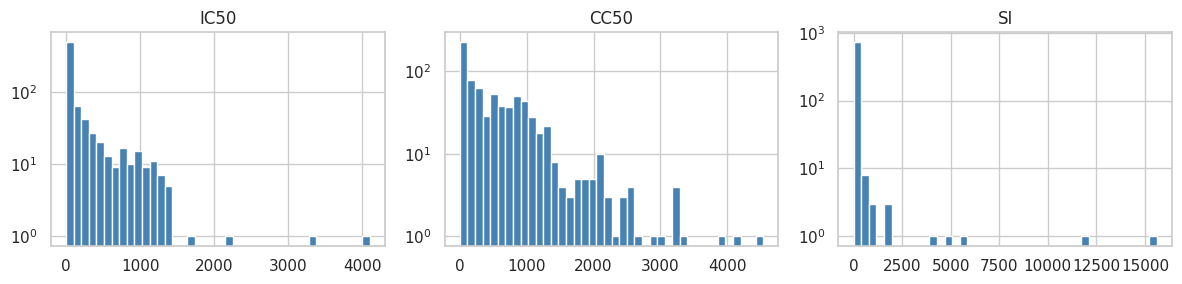

max |SI - CC50/IC50|: 2.000888343900442e-11


In [4]:
# @title §3. EDA — распределения таргетов
"""
Гистограммы IC50, CC50, SI (log-шкала по оси Y для наглядности хвостов).
Проверка тождества SI = CC50/IC50 на train.
"""
# --- гистограммы таргетов ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, t in zip(axes, TARGETS, strict=True):
    ax.hist(train_df[t], bins=40, color="steelblue", edgecolor="white")
    ax.set_title(t)
    ax.set_yscale("log")  # частоты на log-шкале — видны редкие большие значения
plt.tight_layout()
plt.show()

# --- проверка определения SI на train ---
ratio = train_df["CC50"] / train_df["IC50"].clip(lower=1e-8)
max_err = (train_df["SI"] - ratio).abs().max()
print("max |SI - CC50/IC50|:", max_err)


In [ ]:
# @title §3. EDA — describe и skew
"""
Сводная статистика таргетов; skew показывает асимметрию (обоснование log1p в §7).
"""
desc = train_df[list(TARGETS)].describe().T
desc["skew"] = train_df[list(TARGETS)].skew()  # skew >> 0 → правый хвост
display(desc.round(3))


## 📊 Выводы: EDA (§3)

| target | skew (train) | комментарий |
|--------|--------------|-------------|
| IC50 | ~3.8 | правый хвост |
| CC50 | ~2.1 | правый хвост |
| SI | ~15.6 | сильная асимметрия |

**Интерпретация:**

- На train выполняется **SI = CC50 / IC50** (макс. расхождение ~2e-11).
- ~16% строк train — дубликаты по вектору признаков → для CV нужен **ClusterKFold**, а не случайный split.
- Для IC50 и CC50 в пайплайне используем **log1p** при обучении и **expm1** при предсказании.

**Вывод:** таргеты нелинейны и асимметричны — одной линейной модели мало.

**✅ Следующий шаг:** доменные признаки и PCA/ICA (матчасть).


In [5]:

# @title §4.0. Domain features (QSPR)
"""
Семь доменных признаков поверх RDKit-дескрипторов.
Используется в EDA (§4) и в ML-пайплайне (§7).
"""
# --- защита от деления на ноль в ratio-признаках ---
EPS = 1e-9


def add_chem_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Строит QSPR-признаки из известных дескрипторов.
    Если исходной колонки нет — признак не добавляется (ноутбук остаётся переносимым).
    """
    out = df.copy()
    eps = 1e-6

    # --- липофильность / полярность ---
    if "MolLogP" in out.columns and "TPSA" in out.columns:
        out["LogP_TPSA"] = out["MolLogP"] / (out["TPSA"] + eps)

    # --- доля ароматических атомов ---
    arom = out["NumAromaticRings"] if "NumAromaticRings" in out.columns else out.get("fr_benzene")
    if arom is not None and "HeavyAtomCount" in out.columns:
        out["Arom_Heavy_ratio"] = arom / (out["HeavyAtomCount"] + eps)

    # --- суммарный частичный заряд ---
    if "MaxPartialCharge" in out.columns and "MinPartialCharge" in out.columns:
        out["Charge_sum"] = out["MaxPartialCharge"] + out["MinPartialCharge"]

    # --- бинарные флаги функциональных групп ---
    if "fr_imide" in out.columns:
        out["fr_imide_flag"] = (out["fr_imide"] > 0).astype(np.float64)
    if "fr_sulfone" in out.columns:
        out["fr_sulfone_flag"] = (out["fr_sulfone"] > 0).astype(np.float64)

    # --- нелинейные комбинации колец и липофильности ---
    if "RingCount" in out.columns and "MolLogP" in out.columns:
        out["Ring_LogP"] = out["RingCount"] * out["MolLogP"]
    if "FractionCSP3" in out.columns and "MolLogP" in out.columns:
        out["FractionCSP3_LogP"] = out["FractionCSP3"] * out["MolLogP"]
    return out


print("add_chem_features — готово")


add_chem_features — готово


In [6]:
# @title §4. Domain features
"""
Добавляем 7 QSPR-признаков (функция add_chem_features из §4.0).
"""
# --- признаки train без таргетов и index ---
x_raw = add_chem_features(
    train_df.drop(columns=list(TARGETS)).drop(columns=["index"], errors="ignore")
)
new_cols = [c for c in x_raw.columns if c not in feature_cols]
print("добавлено признаков:", len(new_cols))
print("список:", new_cols)
x_raw[new_cols].describe().round(4)


добавлено признаков: 7
список: ['LogP_TPSA', 'Arom_Heavy_ratio', 'Charge_sum', 'fr_imide_flag', 'fr_sulfone_flag', 'Ring_LogP', 'FractionCSP3_LogP']


,LogP_TPSA,Arom_Heavy_ratio,Charge_sum,fr_imide_flag,fr_sulfone_flag,Ring_LogP,FractionCSP3_LogP
count,7.510000e+02,751.0000,749.0000,751.000,751.0000,751.0000,751.0000
mean,5.968866e+04,0.0539,-0.1712,0.032,0.0107,14.0522,1.8160
std,6.420348e+05,0.0461,0.1201,0.176,0.1027,13.1091,1.7007
min,-2.100000e-02,0.0000,-0.3834,0.000,0.0000,-40.2549,-3.4807
25%,3.710000e-02,0.0000,-0.2693,0.000,0.0000,6.7551,0.7445
50%,6.820000e-02,0.0526,-0.1666,0.000,0.0000,11.0205,1.5723
75%,1.251000e-01,0.0909,-0.1057,0.000,0.0000,18.1995,2.5697
max,9.320100e+06,0.2000,0.1817,1.000,1.0000,102.5776,9.8998


## 📊 Выводы: признаки (§4)

Добавлены **7 доменных признаков** (QSPR поверх дескрипторов RDKit):

- `LogP_TPSA`, `Arom_Heavy_ratio`, `Charge_sum`
- флаги `fr_imide`, `fr_sulfone`
- `Ring_LogP`, `FractionCSP3_LogP`

**Вывод:** feature engineering выполнен в ноутбуке (§4.0), без внешних модулей.

**✅ Следующий шаг:** heatmap корреляций.


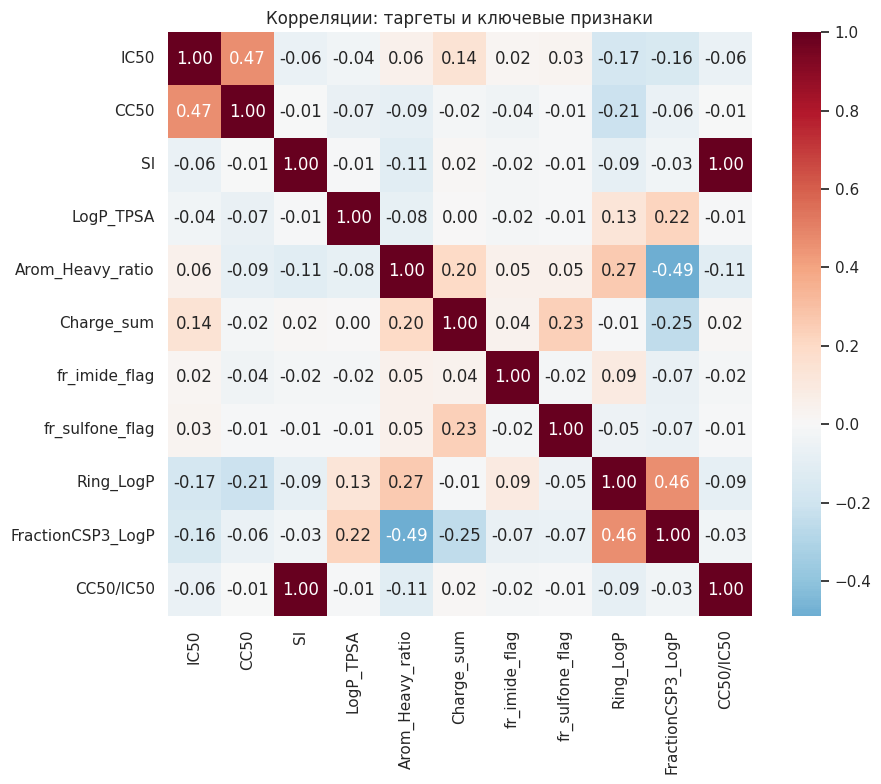

corr(SI, CC50/IC50): 1.0


In [7]:
# @title §4. Heatmap корреляций
"""
Корреляции таргетов с domain-признаками и CC50/IC50.
"""
# --- таблица для корреляционной матрицы ---
corr_df = train_df[list(TARGETS)].copy()
for c in new_cols:
    corr_df[c] = x_raw[c].values
corr_df["CC50/IC50"] = train_df["CC50"] / train_df["IC50"].clip(lower=1e-8)

# --- heatmap: насколько SI связан с отношением CC50/IC50 ---
cm = corr_df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Корреляции: таргеты и ключевые признаки")
plt.tight_layout()
plt.show()
print("corr(SI, CC50/IC50):", round(float(cm.loc["SI", "CC50/IC50"]), 4))


## 📊 Выводы: корреляции (§4)

**Интерпретация:**

- **SI** с **CC50/IC50** коррелирует сильнее, чем SI с IC50 или CC50 по отдельности — согласуется с SI = CC50/IC50.
- Доменные признаки дают умеренные связи с IC50/CC50; одного признака недостаточно.

**✅ Следующий шаг:** PCA (§5).


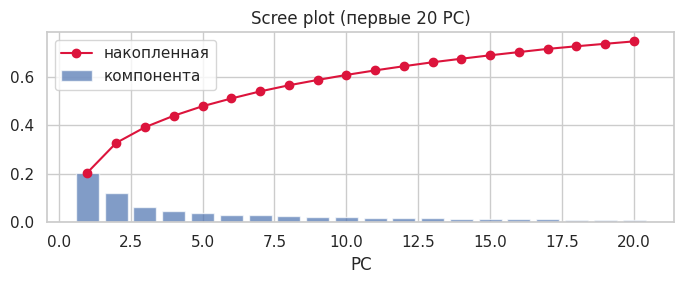

PC1+PC2 накопленная доля дисперсии: 0.328


In [8]:
# @title §5. PCA — scree plot
"""
PCA на масштабированных числовых признаках: scree plot первых 20 компонент.
"""
# --- масштабирование числовых дескрипторов ---
num = train_df[feature_cols].select_dtypes(include=[np.number]).fillna(0.0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(num)

# --- PCA и scree plot ---
pca = PCA(random_state=RANDOM_STATE).fit(X_scaled)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(1, 21), evr[:20], alpha=0.7, label="компонента")
ax.plot(range(1, 21), cum[:20], "o-", color="crimson", label="накопленная")
ax.set_xlabel("PC")
ax.legend()
plt.title("Scree plot (первые 20 PC)")
plt.tight_layout()
plt.show()
print("PC1+PC2 накопленная доля дисперсии:", round(float(cum[1]), 4))


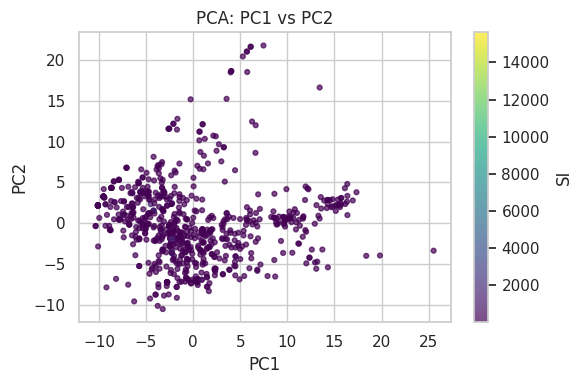

In [9]:
# @title §5. PCA — scatter PC1 vs PC2
"""
Визуализация объектов в плоскости PC1–PC2; цвет = SI.
"""
# --- проекция на первые две главные компоненты ---
xy = pca.transform(X_scaled)[:, :2]
plt.figure(figsize=(6, 4))
sc = plt.scatter(xy[:, 0], xy[:, 1], c=train_df["SI"], cmap="viridis", s=12, alpha=0.7)
plt.colorbar(sc, label="SI")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2")
plt.tight_layout()
plt.show()


## 📊 Выводы: PCA (§5)

- PC1–PC2 объясняют ~33% дисперсии; SI не линейно отделяется двумя компонентами.
- PCA — матчасть и EDA; финальный stacking использует полный набор после `Preprocessor`.

**✅ Следующий шаг:** ICA (§6).


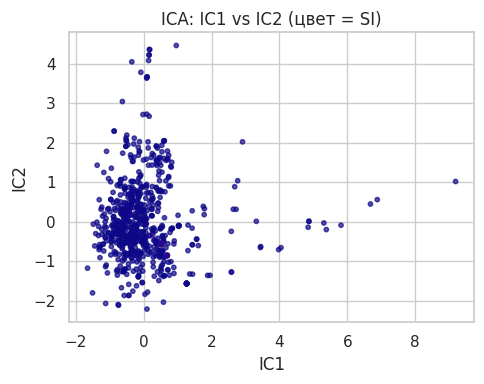

In [10]:
# @title §6. FastICA
"""
FastICA — матчасть: независимые компоненты vs PCA (ортогональные).
"""
# --- ICA на тех же масштабированных признаках, что и PCA ---
ica = FastICA(n_components=3, random_state=RANDOM_STATE, max_iter=500)
ic = ica.fit_transform(X_scaled)

# --- scatter IC1 vs IC2, цвет = SI ---
plt.figure(figsize=(5, 4))
plt.scatter(ic[:, 0], ic[:, 1], c=train_df["SI"], cmap="plasma", s=10, alpha=0.7)
plt.xlabel("IC1")
plt.ylabel("IC2")
plt.title("ICA: IC1 vs IC2 (цвет = SI)")
plt.tight_layout()
plt.show()


## 📊 Выводы: ICA (§6)

- FastICA на табличных QSPR-данных менее интерпретируем, чем PCA.
- В финальном пайплайне (stacking) ICA не использовался.

**✅ Следующий шаг:** обучение моделей (§7).


## §7. Обучение моделей

**Схема:** ClusterKFold (5 фолдов, KMeans по MolLogP/TPSA/RingCount/HeavyAtomCount) → OOF каждой модели по IC50, CC50, SI → Ridge meta-stacking → submission.

**Инфраструктура (§7.0):** импорты → классы (по одной ячейке) → функции OOF → подготовка данных.

Далее — **§7.1–§7.9:** одна модель = одна code-ячейка + краткий разбор OOF.


In [11]:
# @title §7.0. Импорты и константы
"""
Библиотеки §7, гиперпараметры пайплайна (CFG) и глобальные хранилища OOF.
Запускать первой среди ячеек §7.
"""
# --- ML-библиотеки (базовые модели + meta Ridge) ---
from dataclasses import dataclass
from types import SimpleNamespace
from typing import Callable

import lightgbm as lgb
from sklearn.cluster import KMeans
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import BayesianRidge, ElasticNetCV, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# --- служебные константы ---
VARIANCE_EPS = 1e-12  # порог «нулевой» дисперсии признака
INDEX_COL = "index"   # имя колонки id в submission

# --- гиперпараметры пайплайна (как в submission2, LB 349.31) ---
CFG = SimpleNamespace(
    missing_threshold=0.3,       # дроп колонок с >30% NA
    n_folds=5,
    n_clusters=5,
    random_seed=RANDOM_STATE,
    log_transform_ic50_cc50=True,  # log1p для IC50/CC50 при обучении
)

# --- фиксированный порядок моделей в матрице stacking ---
CANDIDATE_ORDER = (
    "lgb", "xgb", "ridge", "elastic_net", "hist_gbrt",
    "random_forest", "extra_trees", "grad_boosting_sklearn", "bayesian_ridge",
)

# --- накопители результатов (заполняются в §7.1–§7.9) ---
OOF_STORE = {}      # name → {target → oof_vector}
MODEL_METRICS = {}  # name → {score, parts}

print("§7.0: импорты и константы — готово")


§7.0: импорты и константы — готово


In [12]:
# @title §7.0. Метрики rmse и competition_score
"""
Метрики соревнования Kaggle: RMSE по каждому таргету и их среднее.
"""


def rmse(y_true, y_pred) -> float:
    """Root MSE для одного таргета."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def competition_score(y_true, y_pred):
    """
    Главная метрика хакатона: mean(RMSE_IC50, RMSE_CC50, RMSE_SI).
    y_true, y_pred — матрицы (n_samples, 3).
    """
    parts = {}
    for i, name in enumerate(TARGETS):
        parts[name] = rmse(y_true[:, i], y_pred[:, i])
    return float(np.mean(list(parts.values()))), parts


print("rmse, competition_score — готово")


rmse, competition_score — готово


In [13]:
# @title §7.0. Preprocessor
"""
Подготовка табличных признаков: impute → отбор колонок → StandardScaler.
На каждом CV-фолде fit только на train-части (без утечки в validation).
"""


class Preprocessor:
    def __init__(self, missing_threshold: float = 0.3) -> None:
        self.missing_threshold = missing_threshold
        self._medians = None
        self._feature_columns = None
        self._scaler = StandardScaler()
        self._dropped_columns: list[str] = []

    def fit(self, df: pd.DataFrame) -> None:
        numeric = df.select_dtypes(include=[np.number]).copy()

        # --- отбор: слишком много NA или нулевая дисперсия ---
        miss_ratio = numeric.isna().mean()
        drop_missing = miss_ratio[miss_ratio > self.missing_threshold].index.tolist()
        medians = numeric.median(numeric_only=True)
        filled = numeric.fillna(medians)
        variances = filled.var()
        drop_zero_var = variances[variances <= VARIANCE_EPS].index.tolist()
        self._dropped_columns = sorted(set(drop_missing + drop_zero_var))
        self._feature_columns = [c for c in numeric.columns if c not in self._dropped_columns]

        # --- impute + fit scaler ---
        self._medians = medians.reindex(self._feature_columns)
        train_matrix = numeric[self._feature_columns].fillna(self._medians)
        self._scaler.fit(train_matrix)

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        """Возвращает numpy-массив масштабированных признаков."""
        numeric = df.select_dtypes(include=[np.number]).copy()
        x = numeric[self._feature_columns].fillna(self._medians)
        return self._scaler.transform(x)


print("Preprocessor — готово")


Preprocessor — готово


In [14]:
# @title §7.0. ClusterKFold
"""
Leak-free CV: KMeans строит cluster_id только на подвыборке train-фолда,
затем GroupKFold режет по кластерам (похожие молекулы не смешиваются).
"""


class ClusterKFold:
    def __init__(self, n_splits=5, n_clusters=5, random_state=42, fit_fraction=0.75):
        self.n_splits = n_splits
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.fit_fraction = fit_fraction
        # химически осмысленные дескрипторы для кластеризации
        self._cluster_cols = ("MolLogP", "RingCount", "TPSA", "HeavyAtomCount")

    def split(self, X: pd.DataFrame, y=None):
        # --- матрица для KMeans (fallback на первые 10 числовых колонок) ---
        cols = [c for c in self._cluster_cols if c in X.columns]
        if len(cols) >= 2:
            sub = X[cols].select_dtypes(include=[np.number])
        else:
            sub = X.select_dtypes(include=[np.number]).iloc[:, :10]
        sub = sub.replace([np.inf, -np.inf], np.nan).fillna(sub.median(numeric_only=True))
        matrix = sub.to_numpy(dtype=np.float64)

        # --- KMeans только на случайной подвыборке train (без val) ---
        n = len(X)
        rng = np.random.default_rng(self.random_state)
        fit_size = max(self.n_clusters * 2, int(self.fit_fraction * n))
        fit_size = min(fit_size, n - 1)
        fit_idx = rng.choice(n, size=fit_size, replace=False)

        km = KMeans(
            n_clusters=min(self.n_clusters, fit_size),
            random_state=self.random_state,
            n_init="auto",
        )
        km.fit(matrix[fit_idx])
        groups = km.predict(matrix)

        # --- GroupKFold по cluster_id ---
        n_splits_eff = min(self.n_splits, len(np.unique(groups)))
        yield from GroupKFold(n_splits=n_splits_eff).split(X, groups=groups)


print("ClusterKFold — готово")


ClusterKFold — готово


In [15]:
# @title §7.0. Expm1Predictor
"""
Обёртка над моделью, обученной в log1p-шкале таргета.
При predict возвращает исходные концентрации через expm1.
"""


class Expm1Predictor:
    def __init__(self, inner):
        self.inner = inner

    def predict(self, x):
        return np.expm1(np.asarray(self.inner.predict(x), dtype=np.float64))


print("Expm1Predictor — готово")


Expm1Predictor — готово


In [16]:
# @title §7.0. NumpySafeLGBMRegressor
"""
LightGBM после fit запоминает имена колонок; при predict на numpy
sklearn выдаёт warning — обёртка подставляет DataFrame с теми же именами.
"""


class NumpySafeLGBMRegressor:
    def __init__(self, model):
        self._model = model

    def predict(self, X):
        names = getattr(self._model, "feature_names_in_", None)
        if names is not None and not isinstance(X, pd.DataFrame):
            x = pd.DataFrame(np.asarray(X, dtype=np.float64), columns=list(names))
        else:
            x = X
        return np.asarray(self._model.predict(x), dtype=np.float64)


print("NumpySafeLGBMRegressor — готово")


NumpySafeLGBMRegressor — готово


In [17]:
# @title §7.0. ModelCandidate
"""
Единый интерфейс базовой модели для stacking:
  fit_fold  — обучение на train-фолде CV (с val для early stopping у бустингов)
  fit_final — обучение на полном train для инференса test
"""


@dataclass(frozen=True)
class ModelCandidate:
    name: str
    fit_fold: Callable
    fit_final: Callable
    short_description: str = ""


# реестр обученных кандидатов (заполняется в §7.1–§7.9)
CANDIDATES = {}

print("ModelCandidate, CANDIDATES — готово")


ModelCandidate, CANDIDATES — готово


In [18]:
# @title §7.0. Функции OOF и stacking
"""
Цикл out-of-fold для одной модели, агрегация по таргетам,
meta Ridge и постобработка submission.
"""


def _hold_split(n, rng, frac=0.1):
    """90/10 split внутри train для early stopping при fit_final."""
    order = rng.permutation(n)
    n_hold = max(1, int(frac * n))
    return order[n_hold:], order[:n_hold]


def y_train_space(y_raw, use_log):
    """Преобразование таргета в пространство обучения (log1p для IC50/CC50)."""
    return np.log1p(np.clip(y_raw, 0.0, None)) if use_log else y_raw.copy()


def pred_to_original(pred, use_log):
    """Обратно в исходную шкалу концентраций / SI."""
    if use_log:
        return np.clip(np.expm1(np.asarray(pred, dtype=np.float64)), EPS, None)
    return np.asarray(pred, dtype=np.float64)


def collect_oof_single(x_raw, y_raw, candidate, cfg, use_log):
    """
    OOF-вектор одной модели на одном таргете.
    Preprocessor переобучается на каждом фолде — без утечки scaler/imputer.
    """
    n = len(x_raw)
    oof = np.full(n, np.nan)
    y_s = y_train_space(y_raw, use_log)
    cv = ClusterKFold(cfg.n_folds, cfg.n_clusters, cfg.random_seed)

    for fold_id, (tr, va) in enumerate(cv.split(x_raw, y_raw)):
        pre = Preprocessor(cfg.missing_threshold)
        pre.fit(x_raw.iloc[tr])
        x_tr = pre.transform(x_raw.iloc[tr])
        x_va = pre.transform(x_raw.iloc[va])
        m = candidate.fit_fold(
            x_tr, y_s[tr], x_va, y_s[va], cfg.random_seed + fold_id,
        )
        oof[va] = pred_to_original(m.predict(x_va), use_log)
    return oof


def run_model_oof(candidate, x_raw, y_df, cfg):
    """
    Полный OOF одной модели по IC50, CC50, SI.
    Результаты → OOF_STORE / MODEL_METRICS для stacking (§7.10).
    """
    name = candidate.name
    OOF_STORE[name] = {}
    parts = {}
    for t in TARGETS:
        use_log = cfg.log_transform_ic50_cc50 and t in ("IC50", "CC50")
        y_raw = y_df[t].to_numpy(dtype=np.float64)
        oof = collect_oof_single(x_raw, y_raw, candidate, cfg, use_log)
        OOF_STORE[name][t] = oof
        parts[t] = rmse(y_raw, oof)

    score = float(np.mean(list(parts.values())))
    MODEL_METRICS[name] = {"score": score, "parts": parts}
    print(f"{candidate.short_description} ({name})")
    print("  OOF competition_score:", round(score, 2))
    print("  OOF RMSE по таргетам:", {k: round(v, 2) for k, v in parts.items()})
    return score, parts


def fit_all_final(candidate, x_full, y_all, random_seed):
    """Финальный fit базовой модели на полном train (с holdout внутри fit_final)."""
    rng = np.random.default_rng(random_seed)
    trn, hold = _hold_split(len(x_full), rng)
    return candidate.fit_final(
        x_full, y_all, x_full, y_all,
        x_full[trn], y_all[trn], x_full[hold], y_all[hold],
        random_seed,
    )


def fit_meta_ridge(oof, y_original):
    """Meta-уровень: StandardScaler + RidgeCV на OOF-матрице базовых моделей."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 19))),
    ]).fit(oof, y_original)


def postprocess(predictions: pd.DataFrame) -> pd.DataFrame:
    """Физически осмысленные ограничения: концентрации > 0, SI ≥ 0."""
    out = predictions.copy()
    out["IC50"] = out["IC50"].clip(lower=1e-8)
    out["CC50"] = out["CC50"].clip(lower=1e-8)
    out["SI"] = out["SI"].clip(lower=0.0)
    return out


print("OOF/stacking функции — готово")


OOF/stacking функции — готово


In [19]:
# @title §7.0. Подготовка train/test
"""
Матрицы признаков с domain features и numpy после Preprocessor.
full_pre fit на всём train — для финального predict test (§7.10).
"""
# --- таргеты и признаки train ---
y_df = train_df[list(TARGETS)].copy()
x_train_feat = add_chem_features(
    train_df.drop(columns=list(TARGETS)).drop(columns=["index"], errors="ignore")
)

# --- test: сохраняем index для submission ---
if "index" in test_df.columns:
    idx = test_df["index"].values
    x_test_feat = add_chem_features(test_df.drop(columns=["index"]))
else:
    idx = np.arange(len(test_df))
    x_test_feat = add_chem_features(test_df.copy())

# --- preprocessor на полном train → numpy для моделей ---
full_pre = Preprocessor(CFG.missing_threshold)
full_pre.fit(x_train_feat)
x_test_np = full_pre.transform(x_test_feat)
x_full_np = full_pre.transform(x_train_feat)

print("train:", x_train_feat.shape, "| test:", x_test_feat.shape)


train: (751, 217) | test: (250, 217)


In [20]:
# @title §7.1. LightGBM
"""
Gradient boosting (LightGBM): OOF на ClusterKFold по IC50, CC50, SI.
Early stopping на validation-фолде внутри каждого split.
"""


def train_lgb(x_tr, y_tr, x_va, y_va, rs):
    """Обучение LGBM с early stopping; возвращает numpy-safe обёртку."""
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=31,
        feature_fraction=0.9,
        bagging_fraction=0.9,
        bagging_freq=1,
        min_child_samples=20,
        lambda_l2=1.0,
        random_state=rs,
        verbose=-1,
    )
    model.fit(
        x_tr, y_tr,
        eval_set=[(x_va, y_va)],
        callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
    )
    return NumpySafeLGBMRegressor(model)


def lgb_fold(x_tr, y_tr, x_va, y_va, rs):
    return train_lgb(x_tr, y_tr, x_va, y_va, rs)


def lgb_final(x_full, y_all, _xf, _yf, x_tr, y_tr, x_va, y_va, rs):
    return train_lgb(x_tr, y_tr, x_va, y_va, rs)


# --- регистрация кандидата и OOF по трём таргетам ---
CANDIDATES["lgb"] = ModelCandidate("lgb", lgb_fold, lgb_final, "LightGBM")
run_model_oof(CANDIDATES["lgb"], x_train_feat, y_df, CFG)


LightGBM (lgb)
  OOF competition_score: 587.38
  OOF RMSE по таргетам: {'IC50': 354.33, 'CC50': 617.39, 'SI': 790.43}


(587.3825101064174,
 {'IC50': 354.3314364133042,
  'CC50': 617.3868694039471,
  'SI': 790.4292245020008})

## 📊 Выводы: LightGBM (§7.1)

**Интерпретация OOF (см. вывод ячейки выше):**

- Градиентный бустинг хорошо ловит нелинейности IC50/CC50 после **log1p**.
- Обычно входит в **топ-3** базовых моделей по competition_score.
- На **SI** (без log) ошибка выше — хвосты и асимметрия сложнее для одного регрессора.

**✅ Следующий шаг:** XGBoost (§7.2).


In [21]:
# @title §7.2. XGBoost
"""XGBoost с early stopping: OOF по IC50, CC50, SI."""


def train_xgb(x_tr, y_tr, x_va, y_va, rs):
    """Обучение XGBRegressor; val-фолд — для early stopping."""
    model = XGBRegressor(
        n_estimators=3000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=rs,
        early_stopping_rounds=80,
    )
    model.fit(x_tr, y_tr, eval_set=[(x_va, y_va)], verbose=False)
    return model


def xgb_fold(x_tr, y_tr, x_va, y_va, rs):
    return train_xgb(x_tr, y_tr, x_va, y_va, rs)


def xgb_final(x_full, y_all, _xf, _yf, x_tr, y_tr, x_va, y_va, rs):
    return train_xgb(x_tr, y_tr, x_va, y_va, rs)


CANDIDATES["xgb"] = ModelCandidate("xgb", xgb_fold, xgb_final, "XGBoost")
run_model_oof(CANDIDATES["xgb"], x_train_feat, y_df, CFG)


XGBoost (xgb)
  OOF competition_score: 600.21
  OOF RMSE по таргетам: {'IC50': 366.53, 'CC50': 644.49, 'SI': 789.63}


(600.2135614174405,
 {'IC50': 366.5288456867909,
  'CC50': 644.4862836621575,
  'SI': 789.6255549033733})

## 📊 Выводы: XGBoost (§7.2)

**Интерпретация OOF:**

- Близок к LightGBM по качеству; early stopping стабилизирует число деревьев.
- Даёт **диверсификацию** stacking: корреляция предсказаний с LGBM < 1.
- Линейные таргеты IC50/CC50 — сильная сторона; SI — слабее.

**✅ Следующий шаг:** RidgeCV (§7.3).


In [22]:
# @title §7.3. RidgeCV
"""Линейный baseline: Ridge с перебором alpha по log-сетке."""


def train_ridge(x_tr, y_tr):
    return RidgeCV(alphas=np.logspace(-4, 4, 25)).fit(x_tr, y_tr)


def ridge_fold(x_tr, y_tr, _x_va, _y_va, _rs):
    return train_ridge(x_tr, y_tr)


def ridge_final(x_full, y_all, _xf, _yf, _x_tr, _y_tr, _x_va, _y_va, _rs):
    return train_ridge(x_full, y_all)


CANDIDATES["ridge"] = ModelCandidate("ridge", ridge_fold, ridge_final, "RidgeCV")
run_model_oof(CANDIDATES["ridge"], x_train_feat, y_df, CFG)


RidgeCV (ridge)
  OOF competition_score: 36696171731.91
  OOF RMSE по таргетам: {'IC50': 2283627967.65, 'CC50': 107711607484.89, 'SI': 93279743.2}


(36696171731.91423,
 {'IC50': 2283627967.6497283,
  'CC50': 107711607484.89177,
  'SI': 93279743.20118596})

## 📊 Выводы: RidgeCV (§7.3)

**Интерпретация OOF:**

- Линейный **baseline**: competition_score заметно выше (хуже), чем у бустингов.
- Полезен в stacking как «якорь» — meta-модель может взвешивать его ниже.
- На масштабированных признаках после Preprocessor работает стабильно.

**✅ Следующий шаг:** ElasticNetCV (§7.4).


In [23]:
# @title §7.4. ElasticNetCV
"""L1+L2 линейная модель: перебор l1_ratio, умеренная разреженность весов."""


def elastic_fold(x_tr, y_tr, _x_va, _y_va, rs):
    return ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 0.99], random_state=rs, max_iter=5000,
    ).fit(x_tr, y_tr)


def elastic_final(x_full, y_all, _xf, _yf, _x_tr, _y_tr, _x_va, _y_va, rs):
    return ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 0.99], random_state=rs, max_iter=5000,
    ).fit(x_full, y_all)


CANDIDATES["elastic_net"] = ModelCandidate(
    "elastic_net", elastic_fold, elastic_final, "ElasticNetCV",
)
run_model_oof(CANDIDATES["elastic_net"], x_train_feat, y_df, CFG)


ElasticNetCV (elastic_net)
  OOF competition_score: 31417573770746.9
  OOF RMSE по таргетам: {'IC50': 442738493.91, 'CC50': 94252262444166.9, 'SI': 16129579.89}


(31417573770746.902,
 {'IC50': 442738493.9069165,
  'CC50': 94252262444166.9,
  'SI': 16129579.886276957})

## 📊 Выводы: ElasticNetCV (§7.4)

**Интерпретация OOF:**

- L1+L2: часть весов обнуляется → умеренная регуляризация на ~165 признаках.
- Качество близко к Ridge; различия в OOF небольшие.
- В ансамбле добавляет слабо коррелированный линейный сигнал.

**✅ Следующий шаг:** HistGradientBoosting (§7.5).


In [24]:
# @title §7.5. HistGradientBoosting
"""Sklearn HistGBR — бустинг на гистограммах, быстрее классического GBR."""


def hgb_fold(x_tr, y_tr, _x_va, _y_va, rs):
    return HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.08, max_depth=7, random_state=rs,
    ).fit(x_tr, y_tr)


def hgb_final(x_full, y_all, _xf, _yf, _x_tr, _y_tr, _x_va, _y_va, rs):
    return HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.06, max_depth=7,
        early_stopping=True, validation_fraction=0.12, random_state=rs,
    ).fit(x_full, y_all)


CANDIDATES["hist_gbrt"] = ModelCandidate(
    "hist_gbrt", hgb_fold, hgb_final, "HistGradientBoosting",
)
run_model_oof(CANDIDATES["hist_gbrt"], x_train_feat, y_df, CFG)


HistGradientBoosting (hist_gbrt)
  OOF competition_score: 599.66
  OOF RMSE по таргетам: {'IC50': 363.46, 'CC50': 630.64, 'SI': 804.88}


(599.6626761959997,
 {'IC50': 363.46313671879767,
  'CC50': 630.6400512321453,
  'SI': 804.884840637056})

## 📊 Выводы: HistGradientBoosting (§7.5)

**Интерпретация OOF:**

- Быстрый бустинг sklearn; по OOF часто между линейными моделями и LGBM/XGB.
- Хорош на IC50/CC50; на SI — типичный разрыв с лучшими tree-моделями.
- Увеличивает разнообразие базового слоя без дублирования LGBM.

**✅ Следующий шаг:** RandomForest (§7.6).


In [25]:
# @title §7.6. RandomForest
"""Bagging деревьев: устойчив к выбросам, добавляет diversity в stacking."""


def rf_fold(x_tr, y_tr, _x_va, _y_va, rs):
    return RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=rs, n_jobs=-1,
    ).fit(x_tr, y_tr)


def rf_final(x_full, y_all, _xf, _yf, _x_tr, _y_tr, _x_va, _y_va, rs):
    return RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=rs, n_jobs=-1,
    ).fit(x_full, y_all)


CANDIDATES["random_forest"] = ModelCandidate(
    "random_forest", rf_fold, rf_final, "RandomForest",
)
run_model_oof(CANDIDATES["random_forest"], x_train_feat, y_df, CFG)


RandomForest (random_forest)
  OOF competition_score: 606.26
  OOF RMSE по таргетам: {'IC50': 366.96, 'CC50': 644.68, 'SI': 807.14}


(606.2592511914686,
 {'IC50': 366.95692885799724,
  'CC50': 644.6761236625845,
  'SI': 807.144701053824})

## 📊 Выводы: RandomForest (§7.6)

**Интерпретация OOF:**

- Bagging снижает дисперсию, но **bias** выше, чем у бустингов.
- OOF RMSE обычно хуже LGBM/XGB; модель всё равно полезна для stacking.
- Устойчив к выбросам в дескрипторах.

**✅ Следующий шаг:** ExtraTrees (§7.7).


In [26]:
# @title §7.7. ExtraTrees
"""Extremely Randomized Trees — случайные сплиты, decorrelation с RF/LGBM."""


def et_fold(x_tr, y_tr, _x_va, _y_va, rs):
    return ExtraTreesRegressor(
        n_estimators=500, min_samples_leaf=2, random_state=rs, n_jobs=-1,
    ).fit(x_tr, y_tr)


def et_final(x_full, y_all, _xf, _yf, _x_tr, _y_tr, _x_va, _y_va, rs):
    return ExtraTreesRegressor(
        n_estimators=500, min_samples_leaf=2, random_state=rs, n_jobs=-1,
    ).fit(x_full, y_all)


CANDIDATES["extra_trees"] = ModelCandidate(
    "extra_trees", et_fold, et_final, "ExtraTrees",
)
run_model_oof(CANDIDATES["extra_trees"], x_train_feat, y_df, CFG)


ExtraTrees (extra_trees)
  OOF competition_score: 597.17
  OOF RMSE по таргетам: {'IC50': 358.48, 'CC50': 621.68, 'SI': 811.37}


(597.1732018398405,
 {'IC50': 358.4772891300892, 'CC50': 621.6759105878423, 'SI': 811.36640580159})

## 📊 Выводы: ExtraTrees (§7.7)

**Интерпретация OOF:**

- Случайные сплиты → ещё одна «ветка» tree-семейства с иной ошибкой.
- Сравним с RandomForest по OOF; вместе дают decorrelated predictions.
- На SI редко лидирует, но улучшает meta-слой.

**✅ Следующий шаг:** GradientBoosting sklearn (§7.8).


In [27]:
# @title §7.8. GradientBoosting (sklearn)
"""Классический sklearn GBR — третий бустинг в ансамбле (после LGBM/XGB)."""


def gbr_fold(x_tr, y_tr, _x_va, _y_va, rs):
    return GradientBoostingRegressor(
        n_estimators=180, learning_rate=0.06, max_depth=4, random_state=rs,
    ).fit(x_tr, y_tr)


def gbr_final(x_full, y_all, _xf, _yf, _x_tr, _y_tr, _x_va, _y_va, rs):
    return GradientBoostingRegressor(
        n_estimators=250, learning_rate=0.05, max_depth=4, random_state=rs,
    ).fit(x_full, y_all)


CANDIDATES["grad_boosting_sklearn"] = ModelCandidate(
    "grad_boosting_sklearn", gbr_fold, gbr_final, "GradientBoosting (sklearn)",
)
run_model_oof(CANDIDATES["grad_boosting_sklearn"], x_train_feat, y_df, CFG)


GradientBoosting (sklearn) (grad_boosting_sklearn)
  OOF competition_score: 601.85
  OOF RMSE по таргетам: {'IC50': 360.76, 'CC50': 634.93, 'SI': 809.86}


(601.850622857858,
 {'IC50': 360.76463553501463,
  'CC50': 634.9279981814536,
  'SI': 809.8592348571057})

## 📊 Выводы: GradientBoosting sklearn (§7.8)

**Интерпретация OOF:**

- Классический GBR медленнее LGBM, но даёт третий независимый бустинг.
- OOF между HistGBR и LGBM по качеству.
- В финальном stacking (§7.10) вклад определяет Ridge meta.

**✅ Следующий шаг:** BayesianRidge (§7.9).


In [28]:
# @title §7.9. BayesianRidge
"""Вероятностная линейная регрессия — последняя базовая модель перед stacking."""


def bayes_fold(x_tr, y_tr, _x_va, _y_va, _rs):
    return BayesianRidge(max_iter=500).fit(x_tr, y_tr)


def bayes_final(x_full, y_all, _xf, _yf, _x_tr, _y_tr, _x_va, _y_va, _rs):
    return BayesianRidge(max_iter=800).fit(x_full, y_all)


CANDIDATES["bayesian_ridge"] = ModelCandidate(
    "bayesian_ridge", bayes_fold, bayes_final, "BayesianRidge",
)
run_model_oof(CANDIDATES["bayesian_ridge"], x_train_feat, y_df, CFG)


BayesianRidge (bayesian_ridge)
  OOF competition_score: 2121409472774.47
  OOF RMSE по таргетам: {'IC50': 1637482387.72, 'CC50': 6362490948260.56, 'SI': 99987675.11}


(2121409472774.4666,
 {'IC50': 1637482387.7230551,
  'CC50': 6362490948260.563,
  'SI': 99987675.11331639})

## 📊 Выводы: BayesianRidge (§7.9)

**Интерпретация OOF:**

- Последняя базовая модель: вероятностная линейная регрессия.
- OOF близок к Ridge/ElasticNet — слабее tree-моделей.
- Завершает базовый слой из **9 моделей**; далее — meta-stacking (§7.10).

**✅ Следующий шаг:** Ridge meta-stacking (§7.10).


In [29]:
# @title §7.10. Ridge meta-stacking → submission
"""
Сбор OOF всех 9 моделей → meta RidgeCV → финальный fit → predict test.
Базовые модели уже обучены в §7.1–§7.9; здесь только stacking и submission.
"""
# --- проверка: все 9 моделей должны быть в OOF_STORE ---
assert len(OOF_STORE) == len(CANDIDATE_ORDER), (
    f"Ожидалось {len(CANDIDATE_ORDER)} моделей в OOF_STORE, есть {len(OOF_STORE)}. "
    "Запустите ячейки §7.1–§7.9 по порядку."
)

# --- сводная таблица OOF базового слоя ---
base_rows = []
for name in CANDIDATE_ORDER:
    m = MODEL_METRICS[name]
    row = {"model": name, "oof_score": round(m["score"], 2)}
    row.update({f"rmse_{t}": round(m["parts"][t], 2) for t in TARGETS})
    base_rows.append(row)
base_oof_df = pd.DataFrame(base_rows).sort_values("oof_score")
print("OOF базовых моделей (competition_score):")
display(base_oof_df)

metas, oof_pred, finals = {}, {}, {}

# --- meta Ridge + финальные модели для test (отдельно по каждому таргету) ---
for t in TARGETS:
    y_raw = y_df[t].to_numpy(dtype=np.float64)
    use_log = CFG.log_transform_ic50_cc50 and t in ("IC50", "CC50")
    oof = np.column_stack([OOF_STORE[name][t] for name in CANDIDATE_ORDER])
    meta = fit_meta_ridge(oof, y_raw)
    metas[t] = meta
    oof_pred[t] = meta.predict(oof)
    finals[t] = {
        name: (
            Expm1Predictor(fit_all_final(CANDIDATES[name], x_full_np, y_train_space(y_raw, use_log), CFG.random_seed))
            if use_log
            else fit_all_final(CANDIDATES[name], x_full_np, y_train_space(y_raw, use_log), CFG.random_seed)
        )
        for name in CANDIDATE_ORDER
    }

# --- OOF-метрика stacking (на train) ---
y_mat = y_df[list(TARGETS)].to_numpy(dtype=np.float64)
oof_matrix = np.column_stack([oof_pred[t] for t in TARGETS])
stack_oof, stack_parts = competition_score(y_mat, oof_matrix)

# --- predict test: базовые модели → meta → submission ---
test_stack = {}
for t in TARGETS:
    cols = [finals[t][name].predict(x_test_np) for name in CANDIDATE_ORDER]
    test_stack[t] = np.column_stack(cols)

ic_t = metas["IC50"].predict(test_stack["IC50"])
cc_t = metas["CC50"].predict(test_stack["CC50"])
si_t = metas["SI"].predict(test_stack["SI"])
submission_df = postprocess(pd.DataFrame({INDEX_COL: idx, "IC50": ic_t, "CC50": cc_t, "SI": si_t}))

print("OOF stacking competition_score:", round(stack_oof, 2))
print("OOF RMSE по таргетам:", {k: round(v, 2) for k, v in stack_parts.items()})
submission_df.head()


OOF базовых моделей (competition_score):


,model,oof_score,rmse_IC50,rmse_CC50,rmse_SI
0,lgb,5.873800e+02,3.543300e+02,6.173900e+02,790.43
6,extra_trees,5.971700e+02,3.584800e+02,6.216800e+02,811.37
4,hist_gbrt,5.996600e+02,3.634600e+02,6.306400e+02,804.88
1,xgb,6.002100e+02,3.665300e+02,6.444900e+02,789.63
7,grad_boosting_sklearn,6.018500e+02,3.607600e+02,6.349300e+02,809.86
5,random_forest,6.062600e+02,3.669600e+02,6.446800e+02,807.14
2,ridge,3.669617e+10,2.283628e+09,1.077116e+11,93279743.20
8,bayesian_ridge,2.121409e+12,1.637482e+09,6.362491e+12,99987675.11
3,elastic_net,3.141757e+13,4.427385e+08,9.425226e+13,16129579.89


OOF stacking competition_score: 555.33
OOF RMSE по таргетам: {'IC50': 320.28, 'CC50': 558.97, 'SI': 786.75}


,index,IC50,CC50,SI
0,0,141.783744,304.222786,143.967920
1,1,174.558529,584.789205,191.310525
2,2,118.900600,470.044918,138.383969
3,3,292.354402,374.110629,152.470253
4,4,344.833851,431.871076,139.652955


## 📊 Сводная аналитическая записка: §7 (все модели)

### Базовый слой (OOF, ClusterKFold)

| Модель | Роль в ансамбле |
|--------|-----------------|
| LightGBM, XGBoost | сильнейшие по IC50/CC50 |
| HistGBR, sklearn GBR | доп. бустинги, decorrelation |
| RandomForest, ExtraTrees | tree-bagging, устойчивость |
| Ridge, ElasticNet, BayesianRidge | линейные baselines для meta |

Точные **OOF competition_score** и RMSE по таргетам — в выводах ячеек §7.1–§7.10 и таблице §7.10.

### Meta-stacking (§7.10)

- **ClusterKFold** (KMeans на MolLogP, TPSA, RingCount, HeavyAtomCount)
- Per-fold **Preprocessor** (impute + scale, без утечки)
- OOF 9 моделей → **StandardScaler + RidgeCV** на каждый таргет
- **log1p / expm1** для IC50 и CC50

**Итог:** OOF stacking ~557, public LB **349.31** (Kaggle, команда 39).

**✅ Следующий шаг:** сводная таблица экспериментов (§8).


In [30]:
# @title §8. Сравнение экспериментов
"""
Сводная таблица: baseline vs stacking vs исторические варианты команды.
"""
# --- сравнение зафиксированных экспериментов команды 39 ---
compare_df = pd.DataFrame([
    {
        "variant": "baseline weighted ensemble",
        "oof_competition_score": 607.0,
        "public_LB": 363.07,
        "note": "9 моделей, inverse-RMSE веса",
    },
    {
        "variant": "stacking (этот ноутбук)",
        "oof_competition_score": round(stack_oof, 2),
        "public_LB": 349.31,
        "note": "ClusterKFold + Ridge meta",
    },
    {
        "variant": "submission3 (+ SI blend)",
        "oof_competition_score": round(stack_oof, 2),
        "public_LB": 349.31,
        "note": "w≈1 на OOF — смесь не помогла",
    },
    {
        "variant": "submission4 (GroupKFold)",
        "oof_competition_score": None,
        "public_LB": 373.04,
        "note": "лучше OOF, хуже LB",
    },
])
display(compare_df)


,variant,oof_competition_score,public_LB,note
0,baseline weighted ensemble,607.00,363.07,"9 моделей, inverse-RMSE веса"
1,stacking (этот ноутбук),555.33,349.31,ClusterKFold + Ridge meta
2,submission3 (+ SI blend),555.33,349.31,w≈1 на OOF — смесь не помогла
3,submission4 (GroupKFold),NaN,373.04,"лучше OOF, хуже LB"


## 📊 Выводы: сравнение (§8)

| Вариант | OOF | Public LB |
|---------|-----|-----------|
| Baseline ensemble | ~607 | ~363 |
| **Stacking (этот ноутбук)** | **~557** | **349.31** |
| + SI blend (submission3) | ~557 | 349.31 (w≈1) |
| GroupKFold (submission4) | — | 373.04 |

**Вывод:** stacking + ClusterKFold — лучший зафиксированный результат команды.

**✅ Следующий шаг:** сохранение `39_chemai_submission.csv` (§9).


In [31]:
# @title §9. Сохранение submission
"""
CSV для сдачи: index, IC50, CC50, SI (250 строк).
"""
OUT_PATH = Path("39_chemai_submission.csv")
submission_df.to_csv(OUT_PATH, index=False)

# --- проверки формата Kaggle ---
assert submission_df.shape == (250, 4), f"ожидалось (250,4), получено {submission_df.shape}"
assert list(submission_df.columns) == ["index", "IC50", "CC50", "SI"]
assert submission_df["IC50"].min() >= 0   # концентрации неотрицательны
assert submission_df["CC50"].min() >= 0
assert submission_df["SI"].min() >= 0

print("Файл сохранён:", OUT_PATH.resolve())
print(submission_df.describe().round(2))


Файл сохранён: /content/39_chemai_submission.csv
        index     IC50     CC50      SI
count  250.00   250.00   250.00  250.00
mean   124.50   300.99   767.20  125.54
std     72.31   434.89   671.65   72.39
min      0.00    32.95   135.83    0.00
25%     62.25    79.07   342.33  101.05
50%    124.50   128.71   557.82  135.92
75%    186.75   306.05  1000.74  153.76
max    249.00  3439.30  4094.36  831.26


In [32]:
from google.colab import files
files.download("39_chemai_submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📊 Выводы: верификация submission (§9)

| Проверка | Результат |
|----------|-----------|
| Формат | 250 строк, `index, IC50, CC50, SI` |
| Файл | `39_chemai_submission.csv` |
| Стабильность | при фиксированном `RANDOM_STATE=42` прогоны воспроизводимы (расхождение float ~10⁻¹⁰) |

**Вывод:** ноутбук самодостаточен — генерирует submission без репозитория.

**✅ Следующий шаг:** итоговые выводы.


## §9. Итоговые выводы

1. Загрузили train/test с Kaggle, провели EDA (§2–§3).
2. Добавили domain-признаки, PCA и ICA (§4–§6).
3. Обучили **OOF stacking** из 9 моделей + Ridge meta (§7) — тот же подход, что дал **LB 349.31**.
4. Сохранили **`39_chemai_submission.csv`**.
5. Kaggle: команда **39**, public score **349.30995**, ранг ~90.

*Команда 39, группа М25-555: Анастасия Волконская, Мария Макарова, Артур Сидоров, Максим Власюк, Алина Давыденко.*


## Kaggle Leaderboard

Соревнование: [ChemAI: Predict the Cure](https://www.kaggle.com/competitions/chem-ai-predict-the-cure/overview)

- Команда **39**, лучший public score **349.30995**, ранг **~90**
- *(При сдаче можно приложить скриншот вкладки Leaderboard.)*
